# 📊 Statistics Learning Notebook with the MPG Dataset

This notebook walks you through fundamental statistical concepts from the ground up, using the **MPG dataset** from Seaborn for hands-on practice.  
We’ll cover:

- Descriptive statistics (central tendency, dispersion)
- Data visualization
- Probability distributions & normality
- Confidence intervals
- Hypothesis testing (t‑tests, ANOVA)
- Correlation and simple linear regression

Let’s dive in!

---

## 1. Setup and Data Loading

First, import the necessary libraries and load the dataset.

In [2]:
# ============================================================
# 01. IMPORTING STATISTICS AND DATA SCIENCE LIBRARIES
# ============================================================
#
# Python libraries provide ready-made tools for numerical
# computation, data analysis, visualization, and statistics.
#
# Common libraries used in this notebook:
#
# NumPy      → numerical computation
# Pandas     → data manipulation
# Matplotlib → general visualization
# Seaborn    → statistical visualization
# SciPy      → scientific and statistical functions
# Statsmodels→ statistical modeling and testing
#
# ============================================================

# NumPy provides arrays and mathematical functions.
# "np" is the conventional alias for NumPy.
import numpy as np

# Pandas provides Series and DataFrame structures for
# working with tabular and structured data.
# "pd" is the conventional alias for Pandas.
import pandas as pd

# pyplot is Matplotlib's interface for creating plots.
# "plt" is the conventional alias.
import matplotlib.pyplot as plt

# Seaborn provides a high-level interface for statistical
# data visualization and works well with Pandas DataFrames.
# "sns" is the conventional alias.
import seaborn as sns


# ============================================================
# STATISTICAL TOOLS
# ============================================================

# Import the SciPy statistics module.
# Statistical functions can then be accessed using:
#
#     stats.function_name(...)
#
from scipy import stats

# Import the Ordinary Least Squares (OLS) function.
# OLS is commonly used for linear regression models.
from statsmodels.formula.api import ols

# Import Tukey's HSD post-hoc test.
# It is commonly used for pairwise comparisons between
# group means after ANOVA.
from statsmodels.stats.multicomp import pairwise_tukeyhsd


# ============================================================
# JUPYTER PLOTTING
# ============================================================
#
# This is an IPython/Jupyter magic command, not standard
# Python syntax.
#
# It makes Matplotlib plots appear directly inside the
# notebook below the cell that creates them.
#
# NOTE:
# This command is intended for Jupyter/IPython notebooks.
#
%matplotlib inline


# ============================================================
# HOW IT WORKS
# ============================================================
#
# Import libraries
#       ↓
# Assign convenient aliases where appropriate
#       ↓
# Import specific statistical functions
#       ↓
# Libraries and functions become available to later cells
#       ↓
# Jupyter displays Matplotlib plots inline
#
# ============================================================
#
# CORE IDEA:
#
# "import" makes a module available.
#
# "import module as alias" gives a module a shorter name:
#
#     import numpy as np
#     np.mean(...)
#
# "from module import function" imports a specific object:
#
#     from scipy import stats
#     stats.ttest_ind(...)
#
# These imports produce no normal output. They simply make
# the required tools available for the rest of the notebook.
#
# ============================================================

When people refer to the mpg dataset in sns (Seaborn), they are talking about a classic, built-in dataset that comes pre-packaged with the Python data visualization library.

Here is a complete breakdown of what it is, how to use it, and exactly what you can do with it.

1. What exactly is the mpg dataset?
Full Name: Fuel Economy (Miles Per Gallon) dataset.

Source: It originates from the UCI Machine Learning Repository and was used in the 1983 American Statistical Association Exposition.

The Data: It contains fuel economy and performance data for 398 cars (from 1970 to 1982).

Columns: It has 9 variables:

|Column | Name |	Type|	Description|
|-------|------|-----|------|
|mpg	|Numeric |(Target)|	Miles per gallon|
 (fuel efficiency).
cylinders	Numeric	Number of cylinders in the engine (e.g., 4, 6, 8).
displacement	Numeric	Engine size (cubic inches).
horsepower	Numeric	Engine power. (Note: Has missing values!)
weight	Numeric	Car weight (lbs).
acceleration	Numeric	Time to go from 0 to 60 mph (seconds).
model_year	Numeric	Year the car was made (e.g., 70, 71, 82).
origin	Categorical	Where the car was made (1=USA, 2=Europe, 3=Japan).
name	String	The model name of the car (e.g., "ford mustang").

In [3]:
# ============================================================
# 02. LOADING AND PREPARING THE MPG DATASET
# ============================================================
#
# Before analyzing data, it is useful to configure the
# visualization style and load the dataset.
#
# The MPG dataset contains information about cars, including
# fuel efficiency, cylinders, horsepower, weight, and model year.
#
# ============================================================

# Set Seaborn's plotting theme.
# "whitegrid" adds a grid to plots, making values easier to read.
sns.set_theme(style="whitegrid")

# Set the default Matplotlib figure size to 10 × 6 inches.
# This applies to figures created after this setting.
plt.rcParams['figure.figsize'] = (10, 6)

# Load Seaborn's built-in MPG dataset into a Pandas DataFrame.
#
# "mpg" is the variable that stores the dataset.
# sns.load_dataset() loads a dataset provided by Seaborn.
mpg = sns.load_dataset('mpg')

# Display the first 5 rows of the DataFrame.
#
# head() returns the first 5 rows by default.
# It is commonly used to quickly inspect a dataset.
mpg.head()


# ============================================================
# HOW IT WORKS
# ============================================================
#
# Set visualization theme
#          ↓
# Set default figure size
#          ↓
# Load the MPG dataset
#          ↓
# Store the dataset in the "mpg" DataFrame
#          ↓
# Display the first 5 rows with head()
#
# ============================================================
#
# CORE IDEA:
#
# Data analysis usually begins by:
#
#     1. Preparing the analysis environment
#     2. Loading the data
#     3. Inspecting the data
#
# "mpg" is a Pandas DataFrame, so methods such as:
#
#     mpg.head()
#     mpg.info()
#     mpg.describe()
#
# can be used to explore the dataset.
#
# ============================================================
#
# EXPECTED OUTPUT:
#
# mpg.head() displays the first 5 rows of the MPG dataset,
# allowing a quick look at its columns and values.
#
# ============================================================

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
# ============================================================
# 03. INSPECTING DATASET SHAPE AND COLUMNS
# ============================================================
#
# Before analyzing a dataset, it is useful to understand its
# basic structure: how many rows it contains and what columns
# are available.
#
# ============================================================

# mpg.shape returns a tuple containing:
#     (number_of_rows, number_of_columns)
#
# For example:
#     (398, 9)
#
# means the dataset has 398 rows and 9 columns.
print("Dataset shape:", mpg.shape)

# mpg.columns returns the names of all columns in the DataFrame.
# This helps identify which variables are available for analysis.
print("Dataset columns:", mpg.columns)


# ============================================================
# HOW IT WORKS
# ============================================================
#
# mpg.shape
#     ↓
# returns (rows, columns)
#     ↓
# print() displays the result
#
# mpg.columns
#     ↓
# returns the column names
#     ↓
# print() displays them
#
# ============================================================
#
# CORE IDEA:
#
#     shape  → tells you the size of the dataset
#     columns → tells you which variables are available
#
# These are useful first checks before performing statistical
# analysis or visualization.
#
# ============================================================
#
# EXPECTED OUTPUT:
#
# The first line displays the dataset dimensions.
# The second line displays the available column names.
#
# ============================================================

Dataset shape: (398, 9)
Dataset columns: Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='str')



---

## 2. Data Exploration and Cleaning

Check for missing values, data types, and get a quick statistical summary.

In [5]:
# ============================================================
# 04. INSPECTING DATAFRAME INFORMATION
# ============================================================
#
# Before analyzing a dataset, it is important to check its
# columns, data types, and missing values.
#
# info() provides a quick structural summary of a DataFrame.
#
# ============================================================

# Display information about the "mpg" DataFrame.
#
# info() shows:
#     - column names
#     - number of non-null values
#     - data types
#     - total number of entries
#
# The difference between the total entries and non-null values
# helps identify missing data.
mpg.info()


# ============================================================
# HOW IT WORKS
# ============================================================
#
# mpg
#  ↓
# Pandas DataFrame
#  ↓
# .info()
#  ↓
# Displays structure, data types, and non-null counts
#
# ============================================================
#
# CORE IDEA:
#
# info() is a quick data-quality check.
#
# Pay particular attention to:
#
#     Non-Null Count → helps identify missing values
#     Dtype          → shows the data type of each column
#
# For example, if a column has 398 entries but only
# 390 non-null values, then 8 values are missing.
#
# ============================================================
#
# EXPECTED OUTPUT:
#
# The output is a summary of the DataFrame rather than a
# returned DataFrame. It is displayed directly by info().
#
# ============================================================

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [6]:
# ============================================================
# 05. SUMMARY STATISTICS
# ============================================================
#
# Descriptive statistics provide a quick numerical summary
# of the dataset.
#
# describe() calculates statistics such as count, mean,
# standard deviation, minimum, quartiles, and maximum.
#
# ============================================================

# Generate descriptive statistics for the numeric columns
# in the "mpg" DataFrame.
#
# By default, describe() summarizes numerical columns.
mpg.describe()


# ============================================================
# HOW IT WORKS
# ============================================================
#
# mpg
#  ↓
# Pandas DataFrame
#  ↓
# .describe()
#  ↓
# Calculates descriptive statistics
#  ↓
# Displays the summary table
#
# ============================================================
#
# CORE IDEA:
#
# The main statistics are:
#
# count → number of non-missing values
# mean  → arithmetic average
# std   → standard deviation, measuring data spread
# min   → minimum value
# 25%   → first quartile (Q1)
# 50%   → median (Q2)
# 75%   → third quartile (Q3)
# max   → maximum value
#
# The quartiles divide the ordered data into four parts.
#
# ============================================================
#
# EXPECTED OUTPUT:
#
# A summary table is displayed for each numeric column.
# It provides a quick overview of the distribution and
# variability of the numerical variables.
#
# ============================================================

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


We see that `horsepower` has missing values. Let's drop those rows for simplicity (or you could impute them later).

In [7]:
# ============================================================
# 06. HANDLING MISSING VALUES
# ============================================================
#
# Missing values are common in real-world datasets.
# Here, rows with a missing "horsepower" value are removed
# before further analysis.
#
# ============================================================

# Remove rows where "horsepower" is missing.
#
# subset=['horsepower'] tells Pandas to check only this column.
# dropna() removes rows containing missing (NaN) values.
#
# .copy() creates an independent DataFrame rather than a view
# of the original DataFrame.
mpg_clean = mpg.dropna(subset=['horsepower']).copy()

# shape[0] returns the number of rows in the DataFrame.
# The f-string inserts this number into the output message.
print(f"Rows after dropping missing: {mpg_clean.shape[0]}")


# ============================================================
# HOW IT WORKS
# ============================================================
#
# mpg
#  ↓
# Check "horsepower" column
#  ↓
# Find missing values
#  ↓
# Remove those rows
#  ↓
# Create independent DataFrame → mpg_clean
#  ↓
# Count remaining rows with shape[0]
#  ↓
# print() displays the result
#
# ============================================================
#
# CORE IDEA:
#
# dropna() is used to remove missing values.
#
#     subset=['horsepower']
#
# means only missing values in "horsepower" determine which
# rows are removed.
#
# The original "mpg" DataFrame remains unchanged.
# The cleaned data is stored in "mpg_clean".
#
# ============================================================
#
# EXPECTED OUTPUT:
#
# The number of rows remaining after removing observations
# with missing horsepower values is displayed.
#
# ============================================================

Rows after dropping missing: 392




## 3. Descriptive Statistics

### 3.1 Measures of Central Tendency

**Mean, Median, Mode** – understand the "center" of the data.


In [22]:
# ============================================================
# 07. MEASURES OF CENTRAL TENDENCY AND RANGE
# ============================================================
#
# Measures of central tendency describe the typical or central
# value of a dataset.
#
#     Mean   → arithmetic average
#     Median → middle value
#     Mode   → most frequently occurring value
#
# Maximum and minimum show the upper and lower values of the data.
#
# ============================================================

# Calculate the arithmetic mean of the "mpg" column.
# np.mean() adds the values and divides by their number.
mean_mpg = np.mean(mpg_clean['mpg'])

# Calculate the median of the "mpg" column.
# np.median() finds the middle value after ordering the data.
median_mpg = np.median(mpg_clean['mpg'])

# Calculate the mode of the "mpg" column.
# mode() returns a Series because a dataset can have multiple modes.
# [0] selects the first mode from that Series.
mode_mpg = mpg_clean['mpg'].mode()[0]

# Display the mean rounded to two decimal places.
# :.2f formats the number with exactly 2 decimal places.
print(f"Mean MPG: {mean_mpg:.2f}")

# Display the median rounded to two decimal places.
print(f"Median MPG: {median_mpg:.2f}")

# Display the mode rounded to two decimal places.
print(f"Mode MPG: {mode_mpg:.2f}")

# max() returns the largest MPG value.
print(f"Max MPG: {mpg_clean['mpg'].max():.2f}")

# min() returns the smallest MPG value.
print(f"Min MPG: {mpg_clean['mpg'].min():.2f}")


# ============================================================
# HOW IT WORKS
# ============================================================
#
# MPG values
#     ↓
# Calculate mean, median, and mode
#     ↓
# Find minimum and maximum
#     ↓
# Format results to 2 decimal places
#     ↓
# print() displays the results
#
# ============================================================
#
# CORE IDEA:
#
# Mean   → average value
# Median → middle value
# Mode   → most frequent value
# Min/Max → smallest/largest values
#
# These statistics provide a quick summary of the center
# and range of the MPG distribution.
#
# ============================================================
#
# IMPORTANT:
#
# mode() can return multiple values when several values have
# the same highest frequency. Using [0] selects only the first
# mode.
#
# ============================================================

Mean MPG: 23.45
Median MPG: 22.75
Mode MPG: 13.00
Max MPG: 46.60
Min MPG: 9.00


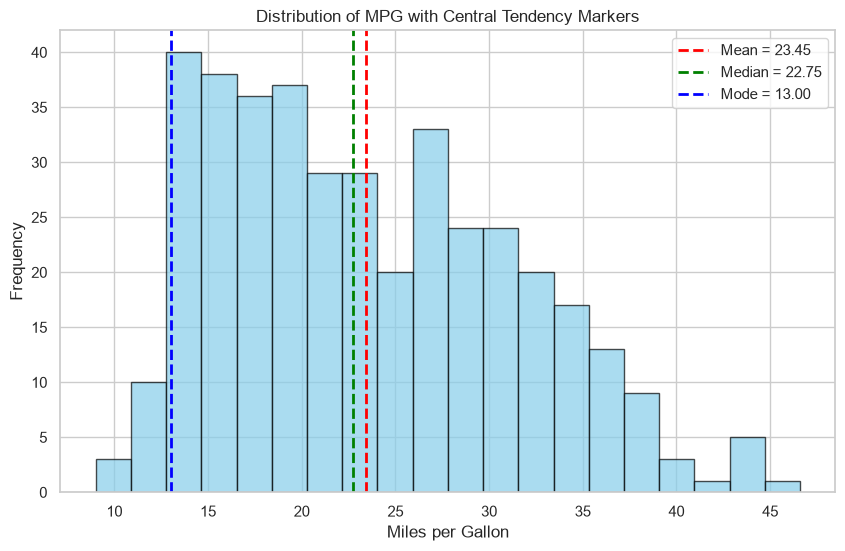

In [23]:
# ============================================================
# 08. VISUALIZING MPG DISTRIBUTION AND CENTRAL TENDENCY
# ============================================================
#
# A histogram shows how numerical values are distributed.
# Vertical lines can be added to mark important statistics
# such as the mean, median, and mode.
#
# ============================================================

# Create a histogram of MPG values.
#
# bins=20 divides the data range into 20 intervals.
# alpha=0.7 controls the transparency of the bars.
# edgecolor='black' adds borders around the bars.
plt.hist(
    mpg_clean['mpg'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)

# Add a vertical line at the mean.
# axvline() draws a vertical line at the specified x-value.
plt.axvline(
    mean_mpg,
    color='red',
    linestyle='dashed',
    linewidth=2,
    label=f'Mean = {mean_mpg:.2f}'
)

# Add a vertical line at the median.
plt.axvline(
    median_mpg,
    color='green',
    linestyle='dashed',
    linewidth=2,
    label=f'Median = {median_mpg:.2f}'
)

# Add a vertical line at the mode.
plt.axvline(
    mode_mpg,
    color='blue',
    linestyle='dashed',
    linewidth=2,
    label=f'Mode = {mode_mpg:.2f}'
)

# Label the x-axis and y-axis.
plt.xlabel('Miles per Gallon')
plt.ylabel('Frequency')

# Add a descriptive title.
plt.title('Distribution of MPG with Central Tendency Markers')

# Display labels for the three vertical lines.
plt.legend()

# Render the completed plot.
plt.show()


# ============================================================
# HOW IT WORKS
# ============================================================
#
# MPG values
#     ↓
# Histogram groups values into bins
#     ↓
# Vertical lines mark mean, median, and mode
#     ↓
# Labels and title are added
#     ↓
# legend() identifies the lines
#     ↓
# show() displays the plot
#
# ============================================================
#
# CORE IDEA:
#
# A histogram shows the shape and frequency of a numerical
# distribution, while the vertical lines help compare its
# central tendency measures visually.
#
# The relative positions of the mean, median, and mode can
# provide clues about the distribution's shape and skewness.
#
# ============================================================


**Interpretation:**  
- **Mean** is sensitive to outliers; **median** is robust.  
- If the distribution is symmetric, mean ≈ median. Here the mean is slightly lower than median, indicating a left skew (more low‑mpg cars).

---

### 3.2 Measures of Dispersion

**Range, Variance, Standard Deviation, IQR** – how spread out is the data?


In [25]:
# ============================================================
# 09. MEASURES OF DISPERSION
# ============================================================
#
# Measures of dispersion describe how spread out the data is.
#
# This section calculates:
#
#     Range → difference between maximum and minimum
#     Variance → squared measure of variability
#     Standard deviation → spread around the mean
#     IQR → spread of the middle 50% of the data
#
# ============================================================

# Extract the "mpg" column from the cleaned DataFrame.
mpg_vals = mpg_clean['mpg']

# Calculate the range: maximum value - minimum value.
# np.ptp() means "peak-to-peak" and calculates this difference.
range_mpg = np.ptp(mpg_vals)

# Calculate the sample variance.
#
# ddof = Delta Degrees of Freedom.
# It determines the denominator used in the calculation.
#
# ddof=0 → divide by N → population variance
# ddof=1 → divide by N-1 → sample variance
#
# N = number of observations.
var_mpg = np.var(mpg_vals, ddof=1)

# Calculate the sample standard deviation.
# Standard deviation is the square root of variance
# and is expressed in the same unit as the original data.
std_mpg = np.std(mpg_vals, ddof=1)

# Calculate the first quartile (Q1).
# 25% of the observations are at or below this value.
q1 = np.percentile(mpg_vals, 25)

# Calculate the third quartile (Q3).
# 75% of the observations are at or below this value.
q3 = np.percentile(mpg_vals, 75)

# Calculate the Interquartile Range (IQR).
# IQR represents the spread of the middle 50% of the data.
iqr = q3 - q1

# Display the calculated statistics with two decimal places.
print(f"Range: {range_mpg:.2f}")
print(f"Sample Variance: {var_mpg:.2f}")
print(f"Sample Standard Deviation: {std_mpg:.2f}")
print(f"Interquartile Range (IQR): {iqr:.2f}")

# max() and min() return the largest and smallest MPG values.
print(f"Max MPG: {mpg_vals.max():.2f}")
print(f"Min MPG: {mpg_vals.min():.2f}")


# ============================================================
# HOW IT WORKS
# ============================================================
#
# MPG values
#     ↓
# Calculate range, variance, and standard deviation
#     ↓
# Calculate Q1 and Q3
#     ↓
# IQR = Q3 - Q1
#     ↓
# Display the results
#
# ============================================================
#
# CORE IDEA:
#
# Range → total spread from minimum to maximum
# Variance → squared measure of variability
# Standard deviation → spread in the original unit
# IQR → spread of the middle 50%
#
# ============================================================
#
# STATISTICAL NOTE:
#
# Python libraries provide the calculation, but parameters such
# as ddof require statistical knowledge to choose correctly.
#
# Here, ddof=1 is used because the calculation treats the data
# as a sample and estimates population variability.
#
# ============================================================

Range: 37.60
Sample Variance: 60.92
Sample Standard Deviation: 7.81
Interquartile Range (IQR): 12.00
Max MPG: 46.60
Min MPG: 9.00


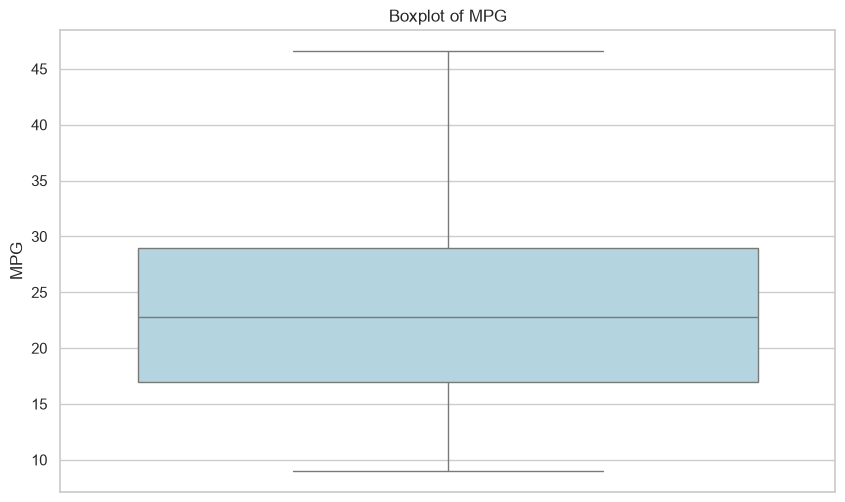

In [26]:
# ============================================================
# 10. BOXPLOT: SPREAD AND OUTLIERS
# ============================================================
#
# A boxplot summarizes the distribution of numerical data.
#
# It shows:
#
#     Median → center line inside the box
#     Q1     → lower edge of the box
#     Q3     → upper edge of the box
#     IQR    → Q3 - Q1, the middle 50% of the data
#     Whiskers → typical range outside the box
#     Outliers → observations beyond the whiskers
#
# ============================================================

# Create a vertical boxplot using the MPG values.
# color='lightblue' sets the color of the box.
sns.boxplot(y=mpg_vals, color='lightblue')

# Set the title of the plot.
plt.title('Boxplot of MPG')

# Set the y-axis label.
plt.ylabel('MPG')

# Display the plot.
plt.show()


# ============================================================
# HOW IT WORKS
# ============================================================
#
# MPG values
#     ↓
# Calculate Q1, median, and Q3
#     ↓
# Calculate IQR = Q3 - Q1
#     ↓
# Draw the box and whiskers
#     ↓
# Identify potential outliers
#
# ============================================================
#
# CORE IDEA:
#
# Boxplot → compact visual summary of distribution,
#           spread, center, and potential outliers.
#
# ============================================================
#
# STATISTICAL NOTE:
#
# By default, Seaborn uses the 1.5 × IQR rule for identifying
# points beyond the whiskers as potential outliers.
#
# Lower boundary = Q1 - 1.5 × IQR
# Upper boundary = Q3 + 1.5 × IQR
#
# ============================================================

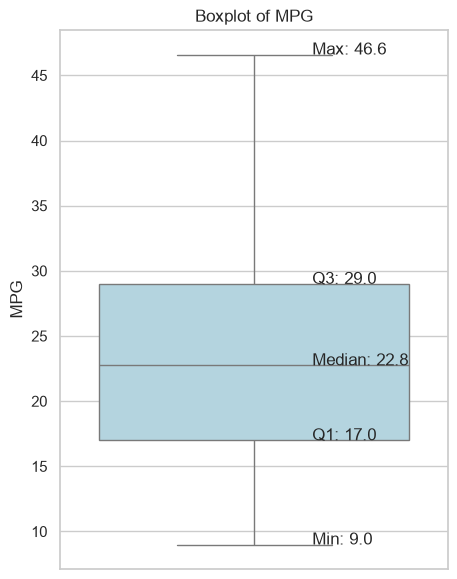

In [12]:
# =====================================================================
# Import Required Libraries
# =====================================================================
# NumPy is used for numerical and statistical calculations.
import numpy as np

# Matplotlib is the core Python library for creating plots.
import matplotlib.pyplot as plt

# Seaborn builds on Matplotlib and provides attractive statistical plots.
import seaborn as sns


# =====================================================================
# Calculate the Five-Number Summary
# =====================================================================
# A boxplot is based on five important descriptive statistics,
# often called the "Five-Number Summary":
#
#   1. Minimum  -> Smallest value in the dataset
#   2. Q1       -> First Quartile (25th percentile)
#   3. Median   -> Middle value (50th percentile)
#   4. Q3       -> Third Quartile (75th percentile)
#   5. Maximum  -> Largest value in the dataset
#
# We calculate these values manually so we can display them
# as labels on the boxplot.
# =====================================================================

# Smallest value in the dataset
minimum = np.min(mpg_vals)

# First Quartile (25th percentile)
# 25% of the observations are less than or equal to this value.
q1 = np.percentile(mpg_vals, 25)

# Median (50th percentile)
# Half of the observations are below this value,
# and half are above it.
median = np.median(mpg_vals)

# Third Quartile (75th percentile)
# 75% of the observations are less than or equal to this value.
q3 = np.percentile(mpg_vals, 75)

# Largest value in the dataset
maximum = np.max(mpg_vals)


# =====================================================================
# Create the Figure
# =====================================================================
# Create a new figure that is:
#   - 5 inches wide
#   - 7 inches tall
#
# A taller figure provides more space for the text labels.
# =====================================================================
plt.figure(figsize=(5, 7))


# =====================================================================
# Draw the Boxplot
# =====================================================================
# Create a vertical boxplot of the MPG values.
#
# The boxplot automatically visualizes:
#   • Minimum
#   • Q1
#   • Median
#   • Q3
#   • Maximum (or whisker endpoint)
#
# The light blue color is used only to improve readability.
# =====================================================================
sns.boxplot(y=mpg_vals, color="lightblue")


# =====================================================================
# Annotate the Statistics
# =====================================================================
# We will place text labels slightly to the right of the boxplot.
#
# Since there is only one boxplot, its x-position is 0.
# Setting x = 0.15 shifts the labels a little to the right so they
# don't overlap with the boxplot.
# =====================================================================
x = 0.15

# Display the minimum value
plt.text(x, minimum, f"Min: {minimum:.1f}")

# Display the first quartile (Q1)
plt.text(x, q1, f"Q1: {q1:.1f}")

# Display the median
plt.text(x, median, f"Median: {median:.1f}")

# Display the third quartile (Q3)
plt.text(x, q3, f"Q3: {q3:.1f}")

# Display the maximum value
plt.text(x, maximum, f"Max: {maximum:.1f}")


# =====================================================================
# Add Labels
# =====================================================================
# Give the plot a descriptive title and label the y-axis.
# =====================================================================
plt.title("Boxplot of MPG")
plt.ylabel("MPG")


# =====================================================================
# Display the Plot
# =====================================================================
# Render the completed figure on the screen.
# =====================================================================
plt.show()

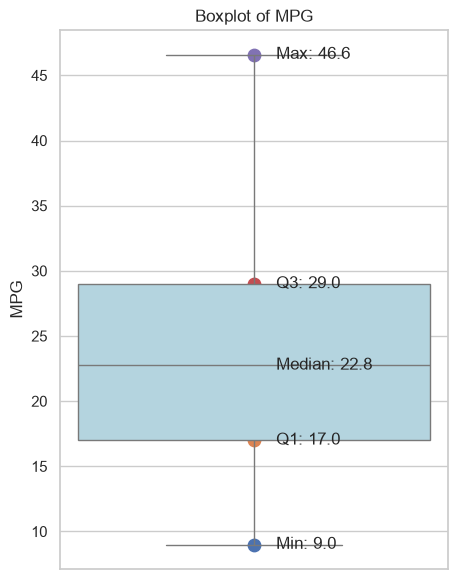

In [13]:
# -------------------------------------------------------------------
# Step 1: Create a new figure (canvas) for the plot.
# figsize=(5, 7) means:
#   - Width  = 5 inches
#   - Height = 7 inches
# Making the figure taller gives more room to display labels clearly.
# -------------------------------------------------------------------
plt.figure(figsize=(5, 7))


# -------------------------------------------------------------------
# Step 2: Draw a boxplot using the MPG (Miles Per Gallon) values.
#
# A boxplot summarizes the distribution of numerical data by showing:
#   • Minimum value
#   • First Quartile (Q1)  -> 25% of the data is below this value
#   • Median               -> Middle value (50th percentile)
#   • Third Quartile (Q3)  -> 75% of the data is below this value
#   • Maximum value
#
# The box is colored light blue only for better visualization.
# -------------------------------------------------------------------
sns.boxplot(y=mpg_vals, color="lightblue")


# -------------------------------------------------------------------
# Step 3: Calculate the five-number summary manually.
#
# Although Seaborn already computes these values internally to draw
# the boxplot, we calculate them ourselves so we can display and
# understand each statistic.
# -------------------------------------------------------------------
stats = {
    # Smallest value in the dataset
    "Min": np.min(mpg_vals),

    # First Quartile (25th percentile)
    # 25% of observations are less than or equal to this value.
    "Q1": np.percentile(mpg_vals, 25),

    # Median (50th percentile)
    # Half of the observations are below this value,
    # and the other half are above it.
    "Median": np.median(mpg_vals),

    # Third Quartile (75th percentile)
    # 75% of observations are below this value.
    "Q3": np.percentile(mpg_vals, 75),

    # Largest value in the dataset
    "Max": np.max(mpg_vals)
}


# -------------------------------------------------------------------
# Step 4: Add markers and text labels to the boxplot.
#
# stats.items() returns each key-value pair:
#   label -> "Min", "Q1", "Median", ...
#   value -> corresponding numerical value
#
# The loop repeats once for every statistic.
# -------------------------------------------------------------------
for label, value in stats.items():

    # Draw a point at x=0 because there is only one boxplot.
    # The y-coordinate is the statistic value.
    # s=80 controls the marker size.
    plt.scatter(0, value, s=80)

    # Add a text label next to the point.
    #
    # x=0.05 shifts the text slightly to the right so it
    # doesn't overlap the marker.
    #
    # value:.1f formats the number with one decimal place.
    #
    # va="center" vertically centers the text relative
    # to the marker.
    plt.text(
        0.05,
        value,
        f"{label}: {value:.1f}",
        va="center"
    )


# -------------------------------------------------------------------
# Step 5: Add descriptive labels.
#
# The title explains what the figure shows.
# The y-axis label tells us what the numerical values represent.
# -------------------------------------------------------------------
plt.title("Boxplot of MPG")
plt.ylabel("MPG")


# -------------------------------------------------------------------
# Step 6: Display the completed figure.
#
# Without plt.show(), some environments (especially Python scripts)
# may not display the plot.
# -------------------------------------------------------------------
plt.show()

**Interpretation:**  
- Standard deviation (≈ 7.8) tells us the average deviation from the mean.  
- IQR gives the range of the middle 50% of data – useful for robust spread measurement.

---

### 3.3 Grouped Statistics

Compare central tendency and dispersion across categories, e.g., **origin**.


In [14]:
# =====================================================================
# Group the Data by Origin
# =====================================================================
# The groupby() method splits the dataset into separate groups based on
# the unique values in the 'origin' column.
#
# In the Auto MPG dataset, the groups are:
#   • USA
#   • Europe
#   • Japan
#
# For each group, we calculate several descriptive statistics for
# the 'mpg' (Miles Per Gallon) column.
# =====================================================================

grouped = mpg_clean.groupby("origin")["mpg"].agg([
    "mean",    # Average MPG for each origin
    "median",  # Middle MPG value for each origin
    "std",     # Standard deviation (measures variability)
    "count"    # Number of vehicles in each origin group
])


# =====================================================================
# Display the Results
# =====================================================================
# The resulting DataFrame contains one row for each origin and one
# column for each calculated statistic.
#
# This allows us to compare fuel efficiency across different regions.
# =====================================================================
grouped

,mean,median,std,count
origin,,,,
europe,27.602941,26.0,6.580182,68
japan,30.450633,31.6,6.090048,79
usa,20.033469,18.5,6.440384,245


Visualise with boxplots:

Text(0.5, 1.0, 'MPG by Origin')

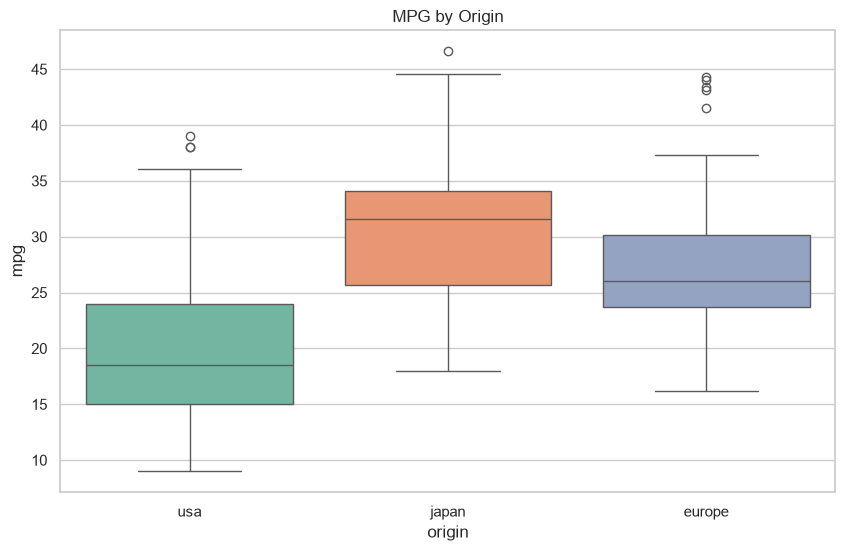

In [15]:
# =====================================================================
# Create a Boxplot to Compare MPG Distribution by Vehicle Origin
# =====================================================================

# A boxplot helps us compare the distribution of a numerical variable
# across different categories.
#
# In this example:
#   - "origin" represents the vehicle manufacturing region/category
#   - "mpg" represents fuel efficiency (Miles Per Gallon)
#
# The boxplot shows:
#   • Median MPG (middle line inside the box)
#   • Q1 and Q3 quartiles (box boundaries)
#   • Data spread (whiskers)
#   • Potential outliers
# =====================================================================

sns.boxplot(
    x="origin",          # Create separate boxplots for each origin group
    y="mpg",             # Compare the distribution of MPG values
    data=mpg_clean,      # Use the cleaned MPG dataset
    
    # Use origin categories to assign different colors to each box.
    # This makes comparisons between groups easier to see.
    hue="origin",
    
    # Select a predefined Seaborn color palette for visualization.
    palette="Set2",
    
    # The colors are already explained by the x-axis categories,
    # so the additional legend is not needed.
    legend=False
)


# Add a title describing the purpose of the visualization
plt.title("MPG by Origin")


# Optional:
# Display the plot manually.
#
# In Jupyter Notebook and VS Code interactive mode, plots are often
# displayed automatically, so this line may not be required.
#
# Uncomment when running as a regular Python script:
# plt.show()

## 4. Data Visualization for Relationships

### 4.1 Scatterplot: MPG vs. Weight

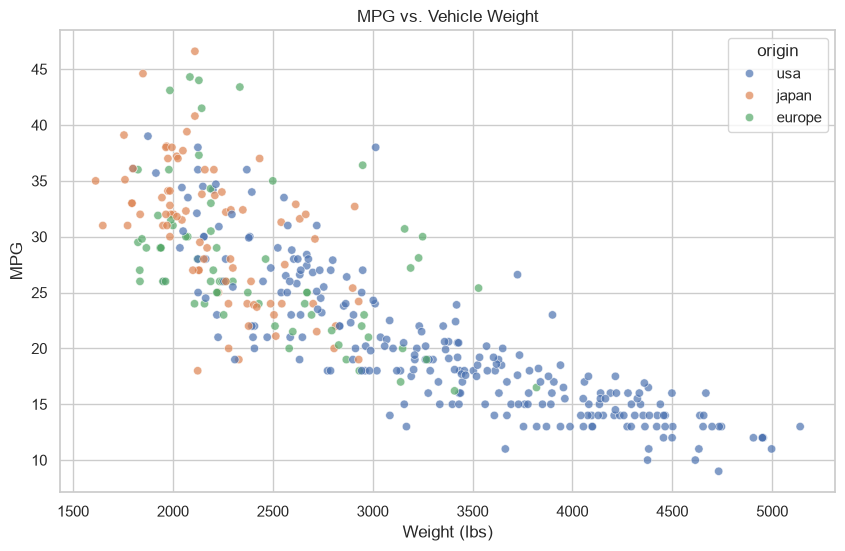

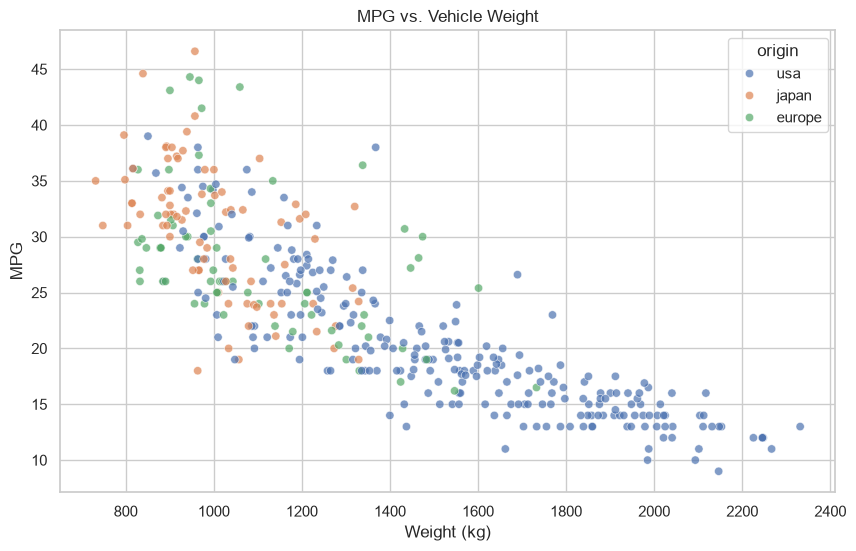

In [16]:
# =====================================================================
# Scatter Plot: Relationship Between Vehicle Weight and Fuel Efficiency
# =====================================================================
# A scatter plot is used to investigate the relationship between two
# numerical variables.
#
# In this example:
#   - Independent variable (X-axis): Vehicle weight
#   - Dependent variable (Y-axis): Fuel efficiency (MPG)
#
# Each point represents one vehicle.
#
# By observing the scatter plot, we can investigate:
#   • Whether heavier vehicles tend to have lower MPG
#   • The strength and direction of the relationship
#   • Possible clusters or unusual observations (outliers)
#
# The points are colored by vehicle origin to compare patterns between
# different regions (USA, Europe, Japan).
# =====================================================================


# ---------------------------------------------------------------------
# Plot 1: Weight in pounds (lbs)
# ---------------------------------------------------------------------
# Create a scatter plot showing the relationship between vehicle weight in pounds
# and fuel efficiency (MPG), with points colored by vehicle origin
sns.scatterplot(
    x="weight",          # Vehicle weight in pounds (lbs)
    y="mpg",             # Fuel efficiency measured in miles per gallon
    data=mpg_clean,      # Use the cleaned MPG dataset
    hue="origin",        # Color points based on vehicle origin
    alpha=0.7            # Make points slightly transparent to see overlaps
)


# Add descriptive labels to the plot
plt.title("MPG vs. Vehicle Weight")  # Set the plot title
plt.xlabel("Weight (lbs)")           # Set the x-axis label
plt.ylabel("MPG")                    # Set the y-axis label


# Display the scatter plot
plt.show()



# =====================================================================
# Plot 2: Weight converted from pounds to kilograms
# =====================================================================
# Scientists and engineers often need to work with different measurement
# units.
#
# The conversion formula is:
#
#     kilograms = pounds × 0.453592
#
# We create the same scatter plot, but display vehicle weight in kg
# instead of lbs.
# =====================================================================


# Create a scatter plot with weight converted from pounds to kilograms
sns.scatterplot(
    x=mpg_clean["weight"] * 0.453592,  # Convert weight from lbs to kg
    y="mpg",                           # Fuel efficiency remains in MPG
    data=mpg_clean,
    hue="origin",                      # Color by vehicle origin
    alpha=0.7                          # Improve visibility of overlapping points
)


# Update labels to reflect the new unit
plt.title("MPG vs. Vehicle Weight")    # Set the plot title
plt.xlabel("Weight (kg)")             # Set the x-axis label with kg unit
plt.ylabel("MPG")                     # Set the y-axis label


# Display the converted-weight scatter plot
plt.show()

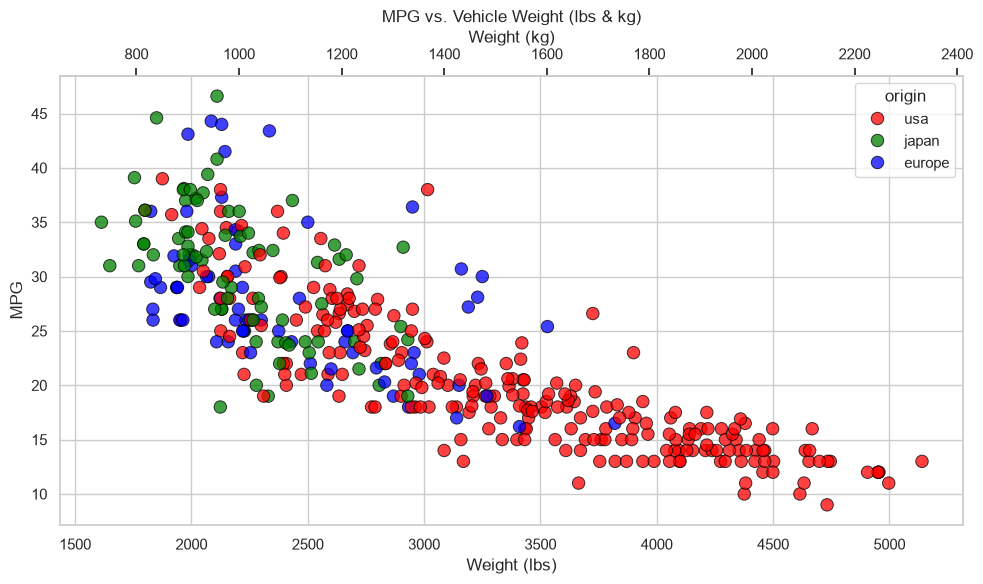

In [17]:
# =====================================================================
# Create a Scatter Plot to Analyze the Relationship Between
# Vehicle Weight and Fuel Efficiency (MPG)
# =====================================================================
#
# A scatter plot shows the relationship between two numerical variables.
#
# In this visualization:
#   - x-axis: Vehicle weight (lbs)
#   - y-axis: Fuel efficiency (MPG)
#   - Color: Vehicle origin category
#
# This helps us understand whether heavier vehicles generally have
# lower MPG and compare patterns between different origins.
#
# Extreme points (possible outliers) are easier to identify because
# each point has a visible border.
# =====================================================================


# Create the figure and the main plotting axis.
fig, ax1 = plt.subplots(figsize=(10, 6))


# =====================================================================
# Create the Scatter Plot
# =====================================================================
#
# Each dot represents one vehicle.
#
# Parameters:
#   x="weight" -> vehicle weight in pounds
#   y="mpg"    -> fuel efficiency (Miles Per Gallon)
#   hue        -> color points according to vehicle origin
#
# The custom palette uses three easily distinguishable colors:
#   Red   -> Origin group 1
#   Blue  -> Origin group 2
#   Green -> Origin group 3
#
# Edge colors and linewidth make individual points clearer and help
# identify unusual observations (possible outliers).
# =====================================================================

sns.scatterplot(
    x="weight",              # Vehicle weight on x-axis (lbs)
    y="mpg",                 # Fuel efficiency on y-axis
    data=mpg_clean,          # Use cleaned MPG dataset
    hue="origin",            # Color points based on vehicle origin
    
    # Three simple and distinguishable colors
    palette={
        "usa": "red",
        "europe": "blue",
        "japan": "green"
    },
    
    s=80,                    # Increase marker size for visibility
    alpha=0.75,              # Add transparency for overlapping points
    
    # Add borders around points to make them easier to see
    edgecolor="black",
    linewidth=0.7,
    
    ax=ax1                   # Draw plot on the main axis
)


# =====================================================================
# Customize the Main Axis
# =====================================================================

ax1.set_xlabel("Weight (lbs)")     # Label x-axis
ax1.set_ylabel("MPG")              # Label y-axis
ax1.set_title("MPG vs. Vehicle Weight (lbs & kg)")


# =====================================================================
# Add Secondary X-axis for Kilograms
# =====================================================================
#
# The original x-axis uses pounds (lbs).
# This secondary axis displays the same weight values in kilograms.
#
# Conversion:
#   kg = lbs × 0.453592
#   lbs = kg ÷ 0.453592
# =====================================================================

ax2 = ax1.secondary_xaxis(
    "top",
    functions=(
        lambda x: x * 0.453592,    # Convert lbs → kg
        lambda x: x / 0.453592     # Convert kg → lbs
    )
)

ax2.set_xlabel("Weight (kg)")      # Label secondary axis


# =====================================================================
# Final Formatting and Display
# =====================================================================

# Automatically adjust spacing between plot elements
plt.tight_layout()

# Display the final plot
plt.show()

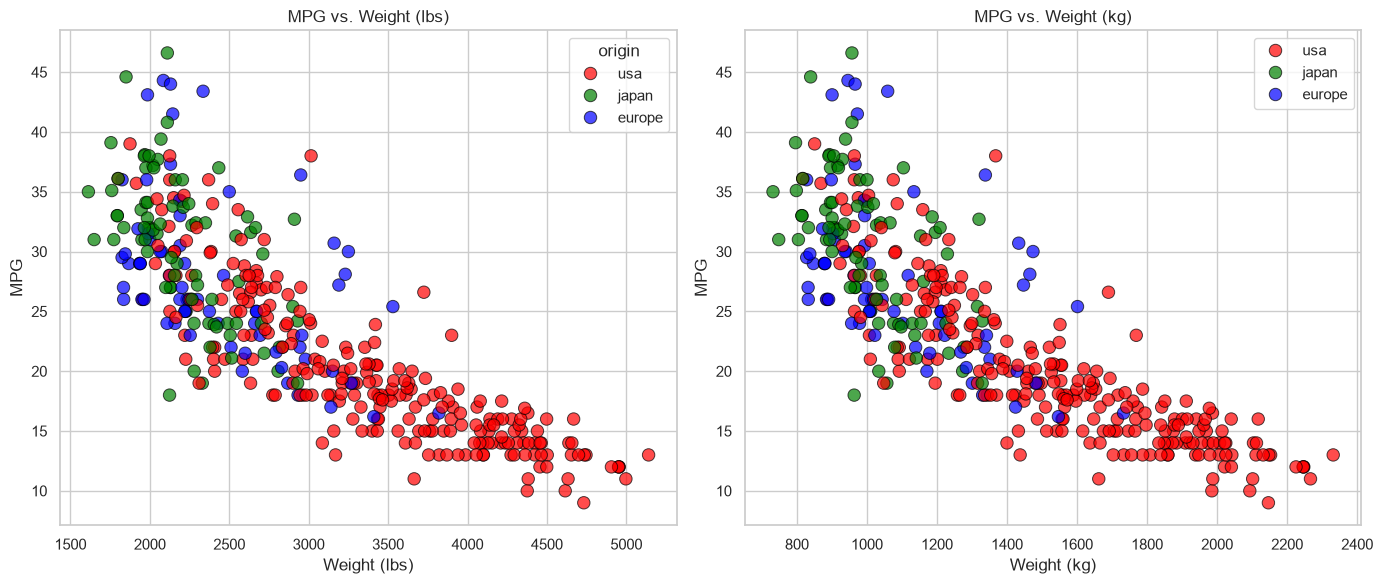

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Pounds
sns.scatterplot(x='weight', y='mpg', data=mpg_clean,
                hue='origin', alpha=0.7, ax=ax1,
                # Three simple and distinguishable colors
    # Define a color palette dictionary for different regions
    palette={
        "usa": "red",          # Color assigned to USA region
        "europe": "blue",      # Color assigned to Europe region
        "japan": "green"       # Color assigned to Japan region
    },
    s=80,                    # Increase marker size for visibility
    # Add borders around points to make them easier to see
    edgecolor="black",
    linewidth=0.7,
                )

ax1.set_title('MPG vs. Weight (lbs)')
ax1.set_xlabel('Weight (lbs)')
ax1.set_ylabel('MPG')

# Plot 2: Kilograms (using your conversion)
sns.scatterplot(x=mpg_clean['weight'] * 0.453592, y='mpg',
                data=mpg_clean, hue='origin', alpha=0.7, ax=ax2,
    # Define a color palette dictionary for different regions
    palette={
        "usa": "red",          # Color assigned to USA region
        "europe": "blue",      # Color assigned to Europe region
        "japan": "green"       # Color assigned to Japan region
    },
    s=80,                    # Increase marker size for visibility
    # Add borders around points to make them easier to see
    edgecolor="black",
    linewidth=0.7,
                )

ax2.set_title('MPG vs. Weight (kg)')
ax2.set_xlabel('Weight (kg)')
ax2.set_ylabel('MPG')

# Remove duplicate legend from second plot (optional)
ax2.legend_.remove()

plt.tight_layout()  # prevents overlapping
plt.legend()
plt.show()


**Observation:** Heavier cars tend to have lower MPG – a negative correlation.

### 4.2 Pairplot of Key Variables

A pairplot is an exploratory visualization that combines multiple scatter plots and distribution plots into a single figure. It provides a comprehensive overview of numerical variables, helping you quickly identify relationships, distributions, clusters, and potential outliers before moving on to more detailed statistical analysis or machine learning.

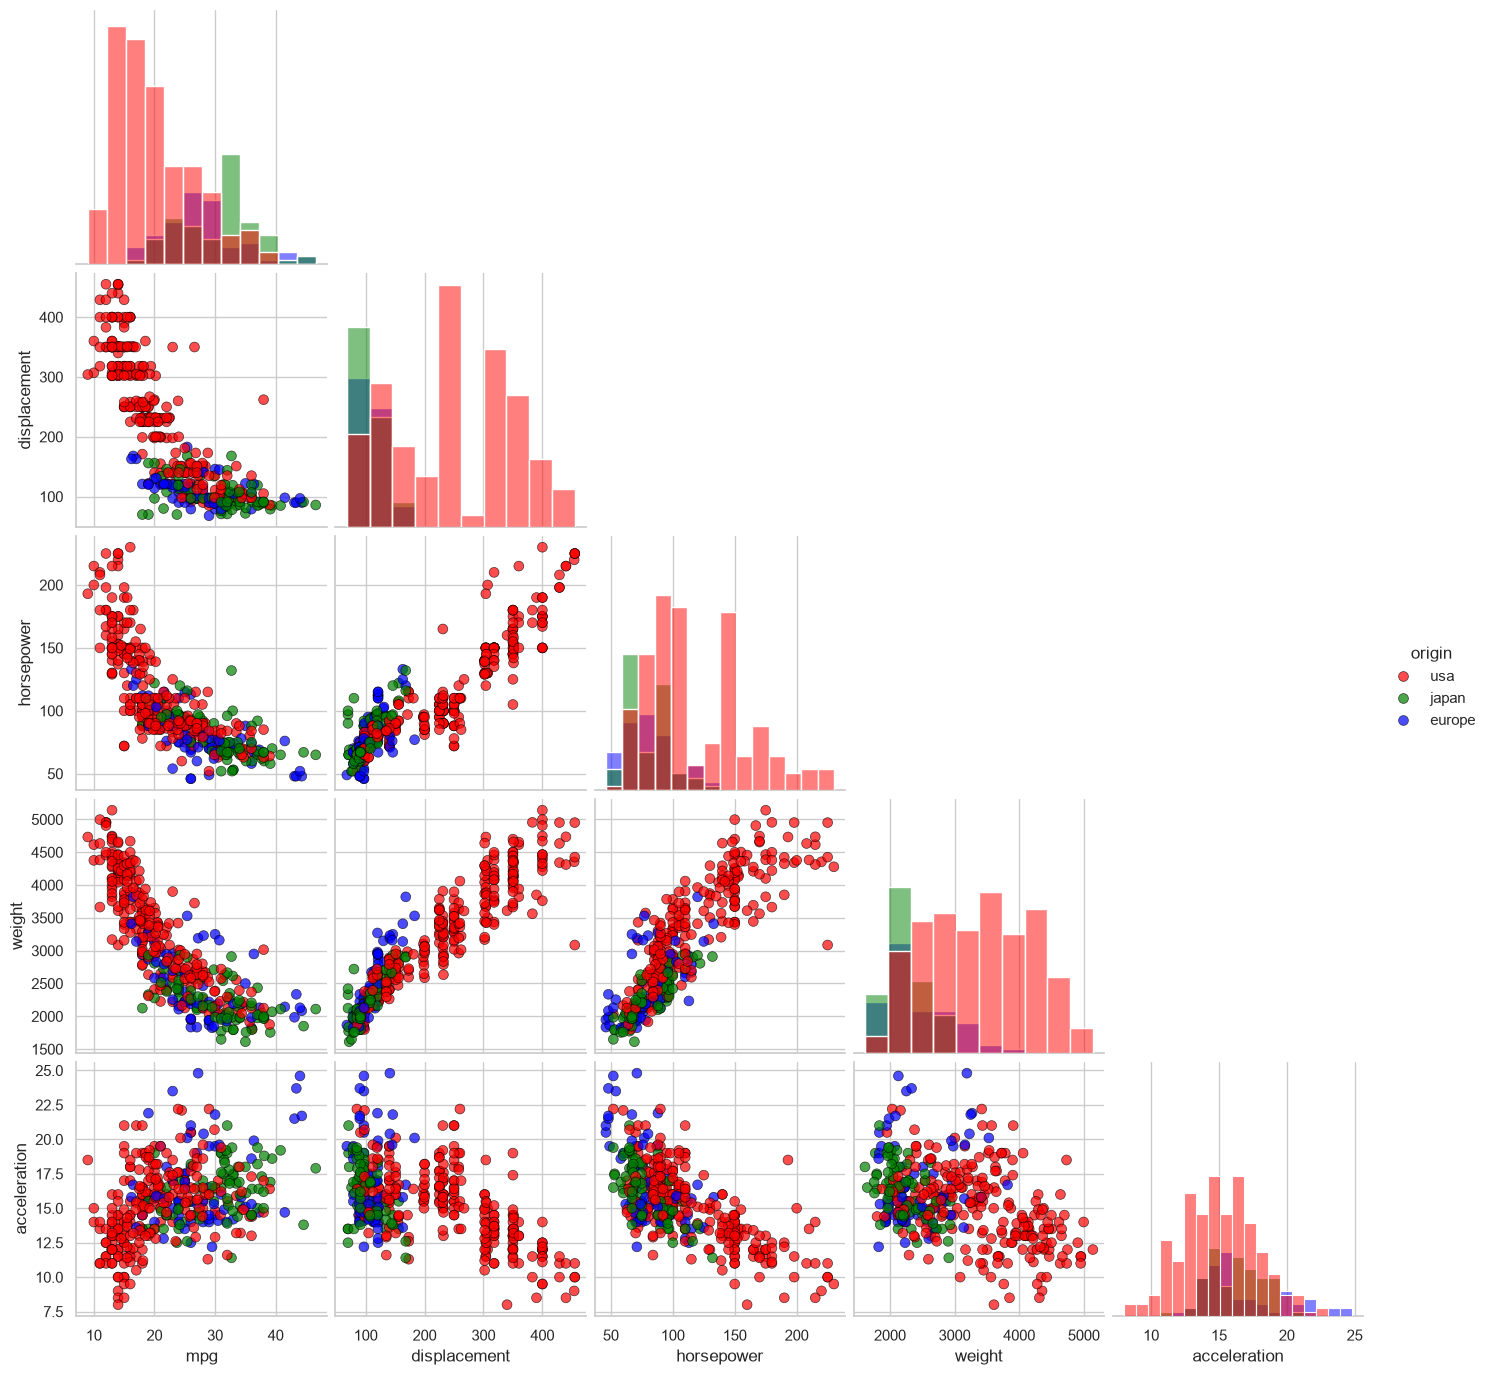

In [19]:
# =====================================================================
# Create a Pairplot to Explore Relationships Between Variables
# =====================================================================
#
# A pairplot is an Exploratory Data Analysis (EDA) visualization that
# displays pairwise relationships between multiple numerical variables
# in a single figure.
#
# The pairplot consists of:
#   • Scatter plots for every pair of numerical variables
#     (off-diagonal cells).
#   • A univariate distribution plot (histogram or KDE) for each
#     variable along the diagonal.
#
# The points are colored according to the vehicle origin, making it
# easier to compare patterns and relationships between different groups.
#
# The selected variables are:
#   • mpg
#   • displacement
#   • horsepower
#   • weight
#   • acceleration
# =====================================================================

# Create a pairplot using seaborn to visualize relationships between multiple variables
sns.pairplot(
    mpg_clean[  # Select specific columns from the cleaned mpg dataset
        [
            "mpg",           # Miles per gallon
            "displacement",  # Engine displacement
            "horsepower",    # Horsepower of the engine
            "weight",        # Weight of the vehicle
            "acceleration",  # Time to accelerate from 0 to 60 mph
            "origin",        # Origin of the vehicle (usa, europe, japan)
        ]
    ],
    hue="origin",  # Color points by origin category
    # palette={  # Define custom colors for each origin category
    #     "usa": "#ff0000",      # Red for USA vehicles
    #     "europe": "#0000ff",   # Blue for European vehicles
    #     "japan": "#00ff00"     # Green for Japanese vehicles
    # }
    
        # Define a color palette dictionary for different regions
# Define colors for each vehicle origin
palette={
    "usa": "red",       # USA vehicles
    "europe": "blue",   # European vehicles
    "japan": "green",   # Japanese vehicles
},

# Customize the appearance of scatter points
plot_kws={
    "s": 50,             # Marker size
    "edgecolor": "black", # Black border around each marker
    "linewidth": 0.5,     # Border thickness
    "alpha": 0.7,         # Marker transparency
},
diag_kind="hist",      # Histogram on the diagonal (default)
# diag_kind="kde",     # Or smooth density curves

corner=True,           # Show only the lower triangle (less repetitive)

height=2.8,            # Size of each subplot

aspect=1              # Square subplots
)

# Display the completed pairplot
plt.show()



## 5. Probability and Distributions

### 5.1 Check Normality of MPG

Many statistical tests assume normality. Let's examine if MPG is normally distributed.


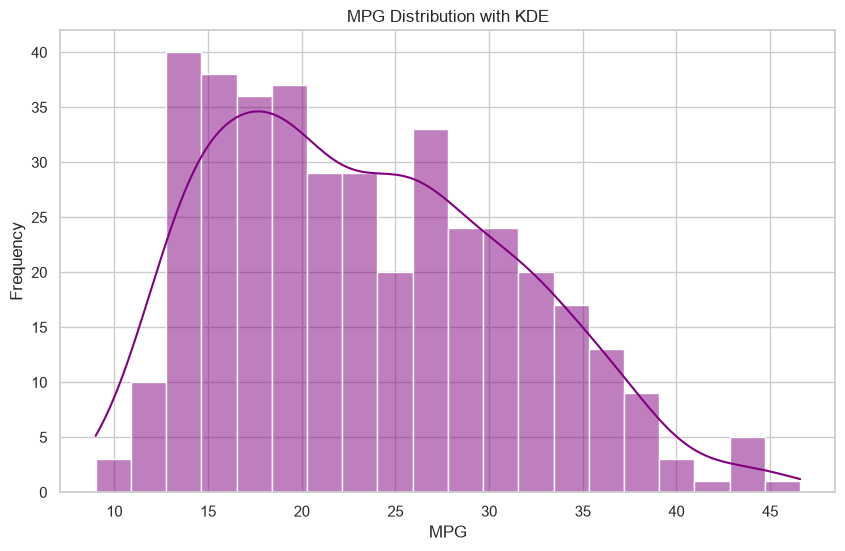

AttributeError: 'dict' object has no attribute 'probplot'

In [20]:
# =====================================================================
# Assess Whether the MPG Data Follows a Normal Distribution
# =====================================================================
#
# Many statistical methods assume that data is approximately normally
# distributed. In this section, we evaluate the normality of the
# 'mpg' variable using three complementary approaches:
#
#   1. Histogram with a Kernel Density Estimate (KDE)
#      - Provides a visual representation of the data distribution.
#      - Helps identify skewness, multiple peaks, or unusual values.
#
#   2. Quantile-Quantile (Q-Q) Plot
#      - Compares the sample data with a theoretical normal distribution.
#      - Points lying close to the reference line indicate that the data
#        is approximately normally distributed.
#
#   3. Shapiro-Wilk Test
#      - A statistical hypothesis test for normality.
#      - Produces a p-value to determine whether the data significantly
#        deviates from a normal distribution.
# =====================================================================


# =====================================================================
# Histogram with Kernel Density Estimate (KDE)
# =====================================================================
#
# Draw a histogram to show the frequency distribution of MPG values.
# The KDE curve provides a smooth estimate of the underlying probability
# density, making the overall shape of the distribution easier to observe.
# =====================================================================

sns.histplot(
    mpg_clean["mpg"],
    bins=20,           # Divide the data into 20 intervals (bins)
    kde=True,          # Overlay a Kernel Density Estimate curve
    color="purple"     # Set the histogram color
)

plt.title("MPG Distribution with KDE")
plt.xlabel("MPG")
plt.ylabel("Frequency")
plt.show()


# =====================================================================
# Quantile-Quantile (Q-Q) Plot
# =====================================================================
#
# Compare the sample quantiles of the MPG data with the quantiles of
# a theoretical normal distribution.
#
# Interpretation:
#   • Points close to the reference line → Data is approximately normal.
#   • Systematic deviations from the line → Data may not be normally
#     distributed.
# =====================================================================

stats.probplot(
    mpg_clean["mpg"],
    dist="norm",       # Compare against a normal distribution
    plot=plt
)

plt.title("Q-Q Plot of MPG")
plt.show()


# =====================================================================
# Shapiro-Wilk Test for Normality
# =====================================================================
#
# Perform the Shapiro-Wilk test to statistically evaluate whether the
# MPG values follow a normal distribution.
#
# Hypotheses:
#   H₀ (Null Hypothesis):
#       The data follows a normal distribution.
#
#   H₁ (Alternative Hypothesis):
#       The data does not follow a normal distribution.
#
# Decision Rule (α = 0.05):
#   • p-value > 0.05 → Fail to reject H₀ (data appears normal)
#   • p-value ≤ 0.05 → Reject H₀ (data is not normally distributed)
# =====================================================================

shapiro_stat, shapiro_p = stats.shapiro(mpg_clean["mpg"])

print(f"Shapiro-Wilk Statistic : {shapiro_stat:.4f}")
print(f"Shapiro-Wilk p-value   : {shapiro_p:.4f}")


**Interpretation:** If p < 0.05, we reject normality. Here p is very small (≈ 0.0), so MPG is not normal. This is common; we'll still perform hypothesis tests but may consider non‑parametric alternatives later.

---

### 5.2 Z‑scores and Standard Normal

Standardising a value: \( z = \frac{x - \mu}{\sigma} \).  
Let's compute z‑scores for MPG and see how many values lie beyond ±2.


In [ ]:
# =====================================================================
# Detect Potential Outliers Using Z-Scores
# =====================================================================
#
# A Z-score measures how many standard deviations an observation is
# above or below the mean.
#
# Formula:
#
#                Value − Mean
#   Z-score = -------------------
#             Standard Deviation
#
# Interpretation:
#   • z = 0   → The value is exactly equal to the mean.
#   • z = 1   → The value is 1 standard deviation above the mean.
#   • z = -1  → The value is 1 standard deviation below the mean.
#
# A common rule of thumb is that observations with:
#   |z| > 2  may be considered unusual.
#   |z| > 3  are often considered potential outliers.
# =====================================================================

# Calculate the Z-score for every MPG observation
z_scores = (mpg_vals - mean_mpg) / std_mpg

# Count the number of observations whose absolute Z-score is greater than 2
outliers = np.sum(np.abs(z_scores) > 2)

# Display the number and percentage of potential outliers
print(f"Number of observations with |z| > 2: {outliers} ({outliers/len(z_scores):.2%})")

Number of observations with |z| > 2: 10 (2.55%)



## 6. Confidence Intervals

Construct a 95% confidence interval for the population mean MPG.


In [ ]:
# =====================================================================
# Calculate a 95% Confidence Interval for the Mean MPG
# =====================================================================
#
# A confidence interval provides a range of plausible values for the
# true population mean based on a sample.
#
# Instead of reporting only a single estimate (the sample mean),
# a confidence interval quantifies the uncertainty associated with
# sampling variability.
#
# A 95% confidence interval means that if we repeatedly collected
# samples and calculated intervals in the same way, approximately
# 95% of those intervals would contain the true population mean.
# =====================================================================

# Import required libraries for numerical operations and statistical functions
import numpy as np
import scipy.stats as stats
# Calculate the sample mean (average MPG)
# This gives us the point estimate for the population mean
sample_mean = np.mean(mpg_vals)

# Calculate the sample standard deviation.
#
# ddof=1 applies Bessel's correction, which produces the sample
# standard deviation rather than the population standard deviation.
# This correction is necessary because we're working with a sample,
# not the entire population.
sample_std = np.std(mpg_vals, ddof=1)

# Determine the sample size (number of observations)
# This will be used for calculating the standard error and degrees of freedom
n = len(mpg_vals)


# =====================================================================
# Calculate the Standard Error of the Mean (SEM)
# =====================================================================
#
# The Standard Error measures how much the sample mean is expected
# to vary from sample to sample.
#
# A larger sample size produces a smaller standard error, resulting
# in a more precise estimate of the population mean.
# =====================================================================

# Calculate the standard error of the mean
# This quantifies the precision of our sample mean estimate
se = sample_std / np.sqrt(n)


# =====================================================================
# Find the Critical t-Value
# =====================================================================
#
# Because the population standard deviation is unknown, we use the
# Student's t-distribution instead of the normal distribution.
#
# For a 95% confidence interval:
#   α = 0.05
#   α/2 = 0.025 in each tail
#
# The cumulative probability of 0.975 corresponds to the upper
# critical value of the t-distribution.
#
# Degrees of freedom:
#   df = n - 1
# =====================================================================

# Calculate the critical t-value for a 95% confidence interval
# Using the t-distribution accounts for additional uncertainty due to
# estimating the population standard deviation from a small sample
t_critical = stats.t.ppf(0.975, df=n - 1)


# =====================================================================
# Calculate the Confidence Interval Bounds
# =====================================================================
#
# Margin of Error:
#   t_critical × Standard Error
#
# Confidence Interval:
#   Sample Mean ± Margin of Error
# =====================================================================

# Calculate the lower bound of the confidence interval
ci_lower = sample_mean - t_critical * se
# Calculate the upper bound of the confidence interval
ci_upper = sample_mean + t_critical * se


# =====================================================================
# Display the Results
# =====================================================================
#
# Interpretation:
# The true average MPG is estimated to lie between the lower and
# upper confidence limits with 95% confidence.
# =====================================================================

# Print the 95% confidence interval for mean MPG with 2 decimal places
print(f"95% CI for mean MPG: ({ci_lower:.2f}, {ci_upper:.2f})")

95% CI for mean MPG: (22.67, 24.22)



Alternatively, use `stats.t.interval`:

In [ ]:
# =====================================================================
# Calculate the 95% Confidence Interval Using SciPy
# =====================================================================
#
# Instead of computing the confidence interval manually, SciPy provides
# the stats.t.interval() function to perform the calculation directly.
#
# Parameters:
#   0.95        -> Confidence level (95%)
#   df=n-1      -> Degrees of freedom for the t-distribution
#   loc         -> Sample mean (center of the interval)
#   scale       -> Standard Error (SE) of the sample mean
#
"""
# The function returns a tuple containing:
#   • Lower confidence limit
#   • Upper confidence limit
"""
# This result should match the confidence interval calculated manually.
# =====================================================================

# Calculate the 95% confidence interval for the population mean
ci = stats.t.interval(
    0.95,             # Confidence level
    df=n - 1,         # Degrees of freedom
    loc=sample_mean,  # Sample mean
    scale=se          # Standard Error of the mean
)

# Display the lower and upper confidence limits
print(f"95% CI using SciPy: ({ci[0]:.2f}, {ci[1]:.2f})")

95% CI using SciPy: (22.67, 24.22)


In [ ]:
ci

(np.float64(22.670877187773105), np.float64(24.22095954692077))

**Interpretation:** We are 95% confident that the true mean MPG lies in this interval.



## 7. Hypothesis Testing

### 7.1 One‑Sample t‑test

Test if the average MPG is significantly different from 25 (a hypothetical value).


In [ ]:
# =====================================================================
# Perform a One-Sample t-Test
# =====================================================================
#
# A one-sample t-test is used to determine whether the mean of a sample
# differs significantly from a known or hypothesized population mean.
#
# In this example, we test whether the average MPG of the vehicles is
# significantly different from 25 MPG.
#
# Hypotheses:
#   H₀ (Null Hypothesis):
#       The population mean MPG is equal to 25.
#       (μ = 25)
#
#   H₁ (Alternative Hypothesis):
#       The population mean MPG is not equal to 25.
#       (μ ≠ 25)
#
# Decision Rule (α = 0.05):
#   • p-value ≤ 0.05 → Reject H₀
#       There is sufficient evidence that the population mean differs
#       from 25 MPG.
#
#   • p-value > 0.05 → Fail to reject H₀
#       There is not enough evidence to conclude that the population
#       mean differs from 25 MPG.
# =====================================================================

# Perform a two-sided one-sample t-test.
#
# Parameters:
#   mpg_vals -> Sample data
#   25       -> Hypothesized population mean (μ₀)
t_stat, p_value = stats.ttest_1samp(mpg_vals, 25)

# Display the test statistic and p-value
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

t-statistic: -3.9422
p-value: 0.0001


**Interpretation:** p < 0.05 → reject H₀, the mean is significantly different from 25.

---

### 7.2 Two‑Sample t‑test (Independent)

Compare MPG between **USA** and **Japan** origins.

In [ ]:
# =====================================================================
# Compare the Mean MPG of USA and Japan Vehicles
# Using an Independent Two-Sample t-Test
# =====================================================================
#
# An independent two-sample t-test is used to determine whether the
# means of two independent groups are significantly different.
#
# In this example, we compare the average MPG of vehicles from:
#   • USA
#   • Japan
#
# Before performing the t-test, we first check whether the two groups
# have equal variances using Levene's test.
# =====================================================================


# =====================================================================
# Extract the MPG Values for Each Group
# =====================================================================
#
# Select the MPG values for vehicles manufactured in the USA and Japan.
# These two independent samples will be compared.
# =====================================================================

usa = mpg_clean[mpg_clean["origin"] == "usa"]["mpg"]
japan = mpg_clean[mpg_clean["origin"] == "japan"]["mpg"]


# =====================================================================
# Perform Levene's Test for Equality of Variances
# =====================================================================
#
# Levene's test evaluates whether the variances of the two groups are
# statistically equal.
#
# Hypotheses:
#   H₀ (Null Hypothesis):
#       The group variances are equal.
#
#   H₁ (Alternative Hypothesis):
#       The group variances are different.
#
# Decision Rule (α = 0.05):
#   • p-value > 0.05 → Assume equal variances.
#   • p-value ≤ 0.05 → Variances are significantly different.
# =====================================================================

levene_stat, levene_p = stats.levene(usa, japan)

print(f"Levene's test statistic: {levene_stat:.4f}")
print(f"Levene's test p-value: {levene_p:.4f}")


# =====================================================================
# Perform the Independent Two-Sample t-Test
# =====================================================================
#
# Choose the appropriate version of the t-test based on the result of
# Levene's test:
#
#   • If variances are equal:
#       Perform the standard Student's t-test.
#
#   • If variances are unequal:
#       Perform Welch's t-test, which does not assume equal variances.
# =====================================================================

equal_var = levene_p > 0.05

t_stat2, p_val2 = stats.ttest_ind(
    usa,
    japan,
    equal_var=equal_var
)


# =====================================================================
# Display the Test Results
# =====================================================================
#
# The t-statistic measures the standardized difference between the
# sample means.
#
# The p-value indicates whether the observed difference is statistically
# significant.
#
# Decision Rule (α = 0.05):
#   • p-value ≤ 0.05 → Reject H₀
#       There is a statistically significant difference between the
#       average MPG of USA and Japan vehicles.
#
#   • p-value > 0.05 → Fail to reject H₀
#       There is insufficient evidence to conclude that the average MPG
#       differs between the two groups.
# =====================================================================

print(f"t-statistic: {t_stat2:.4f}")
print(f"p-value: {p_val2:.4f}")

Levene's test statistic: 0.1616
Levene's test p-value: 0.6879
t-statistic: -12.6649
p-value: 0.0000


**Interpretation:** p is very small → reject H₀, there is a significant difference in MPG between US and Japanese cars.

---

### 7.3 ANOVA (Analysis of Variance)

Compare MPG across **number of cylinders** (4, 6, 8).


In [ ]:
# =====================================================================
# Compare the Mean MPG Across Different Cylinder Groups
# Using a One-Way ANOVA
# =====================================================================
#
# A One-Way Analysis of Variance (ANOVA) is used to determine whether
# the means of three or more independent groups are significantly
# different.
#
# In this example, we compare the average MPG of vehicles with:
#   • 4 cylinders
#   • 6 cylinders
#   • 8 cylinders
#
# Rather than performing multiple t-tests, ANOVA tests all groups
# simultaneously while controlling the overall Type I error rate.
# =====================================================================


# =====================================================================
# Extract the MPG Values for Each Cylinder Group
# =====================================================================
#
# Create a list containing the MPG values for vehicles with
# 4, 6, and 8 cylinders.
#
# Each element in the list represents one independent sample.
# =====================================================================

# Create a list of groups containing MPG values for different cylinder counts
groups = [
    mpg_clean[mpg_clean["cylinders"] == c]["mpg"]  # Select MPG values for each specific cylinder count (4, 6, 8)
    for c in [4, 6, 8]  # Iterate through cylinder counts 4, 6, and 8
]


# =====================================================================
# Perform the One-Way ANOVA
# =====================================================================
#
# Hypotheses:
#
#   H₀ (Null Hypothesis):
#       The mean MPG is the same for all cylinder groups.
#
#       μ₄ = μ₆ = μ₈
#
#   H₁ (Alternative Hypothesis):
#       At least one group has a different mean MPG.
#
# The F-statistic compares:
#   • Between-group variation (differences among group means)
#   • Within-group variation (variation inside each group)
#
# A larger F-statistic provides stronger evidence that the group means
# are not all equal.
# =====================================================================

f_stat, p_anova = stats.f_oneway(*groups) 


# =====================================================================
# Display the ANOVA Results
# =====================================================================
#
# Decision Rule (α = 0.05):
#
#   • p-value ≤ 0.05 → Reject H₀
#       There is a statistically significant difference between
#       the mean MPG of at least one cylinder group.
#
#   • p-value > 0.05 → Fail to reject H₀
#       There is insufficient evidence to conclude that the group
#       means differ.
#
# Note:
# ANOVA tells us that a difference exists, but it does NOT identify
# which specific groups are different. If the ANOVA is significant,
# a post-hoc test (such as Tukey's HSD) should be performed to identify
# the groups that differ.
# =====================================================================

print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA p-value: {p_anova:.4f}")

ANOVA F-statistic: 345.9404
ANOVA p-value: 0.0000


In [ ]:
# =====================================================================
# Compare the Mean MPG Across Different Cylinder Groups
# Using a One-Way ANOVA
# =====================================================================
#
# A One-Way Analysis of Variance (ANOVA) is used to determine whether
# the means of three or more independent groups are significantly
# different.
#
# In this example, we compare the average MPG of vehicles with:
#   • 4 cylinders
#   • 6 cylinders
#   • 8 cylinders
#
# Rather than performing multiple t-tests, ANOVA tests all groups
# simultaneously while controlling the overall Type I error rate.
# =====================================================================


# =====================================================================
# Extract the MPG Values for Each Cylinder Group
# =====================================================================
#
# Create a list containing the MPG values for vehicles with
# 4, 6, and 8 cylinders.
#
# Each element in the list represents one independent sample.
# =====================================================================

groups = [
    mpg_clean[mpg_clean["cylinders"] == c]["mpg"]
    for c in [4, 6, 8]
]


# =====================================================================
# Perform the One-Way ANOVA
# =====================================================================
#
# Hypotheses:
#
#   H₀ (Null Hypothesis):
#       The mean MPG is the same for all cylinder groups.
#
#       μ₄ = μ₆ = μ₈
#
#   H₁ (Alternative Hypothesis):
#       At least one group has a different mean MPG.
#
# The F-statistic compares:
#   • Between-group variation (differences among group means)
#   • Within-group variation (variation inside each group)
#
# A larger F-statistic provides stronger evidence that the group means
# are not all equal.
# =====================================================================

f_stat, p_anova = stats.f_oneway(*groups)


# =====================================================================
# Display the ANOVA Results
# =====================================================================
#
# Decision Rule (α = 0.05):
#
#   • p-value ≤ 0.05 → Reject H₀
#       There is a statistically significant difference between
#       the mean MPG of at least one cylinder group.
#
#   • p-value > 0.05 → Fail to reject H₀
#       There is insufficient evidence to conclude that the group
#       means differ.
#
# Note:
# ANOVA tells us that a difference exists, but it does NOT identify
# which specific groups are different. If the ANOVA is significant,
# a post-hoc test (such as Tukey's HSD) should be performed to identify
# the groups that differ.
# =====================================================================

print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA p-value: {p_anova:.4f}")

ANOVA F-statistic: 345.9404
ANOVA p-value: 0.0000


If significant, perform **post‑hoc** (Tukey HSD) to see which groups differ.


In [ ]:
# =====================================================================
# Perform Tukey's Honestly Significant Difference (HSD) Test
# =====================================================================
#
# After a significant One-Way ANOVA result, we know that at least one
# group mean is different, but we do not know which groups differ.
#
# Tukey's HSD is a post-hoc multiple comparison test that compares
# every possible pair of group means while controlling the overall
# probability of making a Type I error (false positive).
#
# In this example, we compare the mean MPG of vehicles with:
#   • 4 cylinders
#   • 6 cylinders
#   • 8 cylinders
# =====================================================================


# =====================================================================
# Perform Tukey's HSD Test
# =====================================================================
#
# Parameters:
#   endog  -> Numerical response variable (MPG)
#   groups -> Grouping variable (Number of cylinders)
#   alpha  -> Significance level (5%)
# =====================================================================

tukey = pairwise_tukeyhsd(
    endog=mpg_clean["mpg"],          # Response variable to compare
    groups=mpg_clean["cylinders"],   # Group labels
    alpha=0.05                       # Significance level (95% confidence)
)


# =====================================================================
# Display the Pairwise Comparison Results
# =====================================================================
#
# The output table includes:
#
#   • group1   -> First group being compared
#   • group2   -> Second group being compared
#   • meandiff -> Difference between the two group means
#   • p-adj    -> Adjusted p-value for multiple comparisons
#   • lower    -> Lower bound of the 95% confidence interval
#   • upper    -> Upper bound of the 95% confidence interval
#   • reject   -> Whether the null hypothesis is rejected
#
# Interpretation:
#   • reject = True
#       The two groups have significantly different mean MPG values.
#
#   • reject = False
#       There is no statistically significant difference between the
#       mean MPG values of the two groups.
# =====================================================================

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     3      4   8.7339 0.0025   2.2306  15.2373   True
     3      5   6.8167 0.3193   -3.019  16.6524  False
     3      6  -0.5765 0.9993  -7.1688   6.0158  False
     3      8  -5.5869 0.1367 -12.1497   0.9759  False
     4      5  -1.9173 0.9561  -9.4082   5.5737  False
     4      6  -9.3104    0.0 -10.9931  -7.6277   True
     4      8 -14.3208    0.0  -15.884 -12.7576   True
     5      6  -7.3932 0.0592 -14.9614   0.1751  False
     5      8 -12.4036 0.0001 -19.9461   -4.861   True
     6      8  -5.0104    0.0  -6.9099  -3.1109   True
------------------------------------------------------


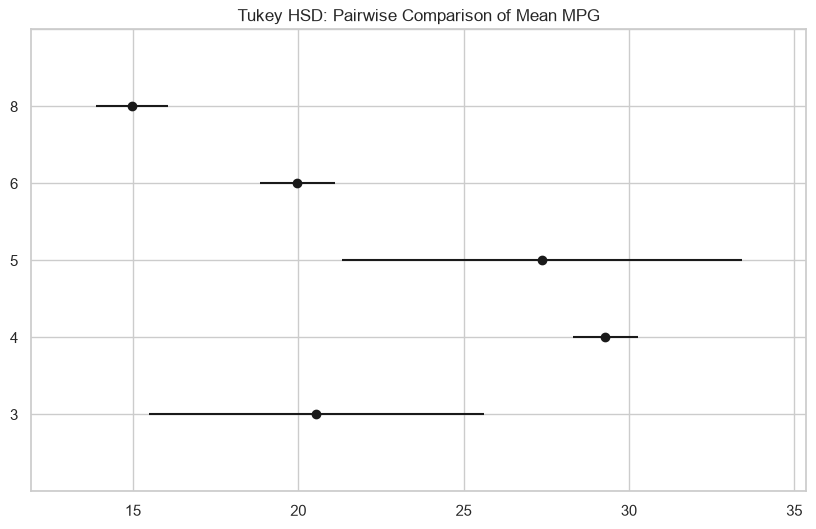

In [ ]:
# Visualize the pairwise comparison results
tukey.plot_simultaneous()
plt.title("Tukey HSD: Pairwise Comparison of Mean MPG")
plt.show()

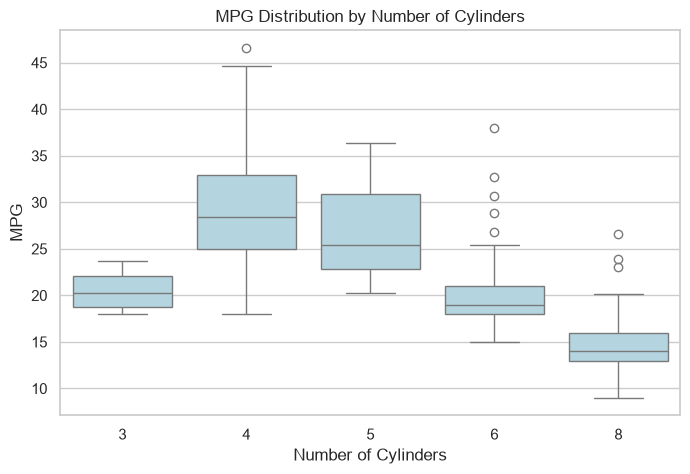

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     3      4   8.7339 0.0025   2.2306  15.2373   True
     3      5   6.8167 0.3193   -3.019  16.6524  False
     3      6  -0.5765 0.9993  -7.1688   6.0158  False
     3      8  -5.5869 0.1367 -12.1497   0.9759  False
     4      5  -1.9173 0.9561  -9.4082   5.5737  False
     4      6  -9.3104    0.0 -10.9931  -7.6277   True
     4      8 -14.3208    0.0  -15.884 -12.7576   True
     5      6  -7.3932 0.0592 -14.9614   0.1751  False
     5      8 -12.4036 0.0001 -19.9461   -4.861   True
     6      8  -5.0104    0.0  -6.9099  -3.1109   True
------------------------------------------------------


,group1,group2,meandiff,p-adj,lower,upper,reject
0,3,4,8.7339,0.0025,2.2306,15.2373,True
1,3,5,6.8167,0.3193,-3.0190,16.6524,False
2,3,6,-0.5765,0.9993,-7.1688,6.0158,False
3,3,8,-5.5869,0.1367,-12.1497,0.9759,False
4,4,5,-1.9173,0.9561,-9.4082,5.5737,False
5,4,6,-9.3104,0.0000,-10.9931,-7.6277,True
6,4,8,-14.3208,0.0000,-15.8840,-12.7576,True
7,5,6,-7.3932,0.0592,-14.9614,0.1751,False
8,5,8,-12.4036,0.0001,-19.9461,-4.8610,True
9,6,8,-5.0104,0.0000,-6.9099,-3.1109,True


Significant pairwise differences:


,group1,group2,meandiff,p-adj,lower,upper,reject
0,3,4,8.7339,0.0025,2.2306,15.2373,True
5,4,6,-9.3104,0.0000,-10.9931,-7.6277,True
6,4,8,-14.3208,0.0000,-15.8840,-12.7576,True
8,5,8,-12.4036,0.0001,-19.9461,-4.8610,True
9,6,8,-5.0104,0.0000,-6.9099,-3.1109,True


In [ ]:
# =====================================================================
# Perform Tukey's Honestly Significant Difference (HSD) Test
# =====================================================================
#
# After performing One-Way ANOVA, if the result is significant, we need
# to determine which specific groups are different.
#
# Tukey's HSD is a post-hoc multiple comparison test that compares all
# possible pairs of groups while controlling the Type I error rate.
#
# In this example, we compare MPG between different cylinder groups:
#   • 4 cylinders
#   • 6 cylinders
#   • 8 cylinders
# =====================================================================


# =====================================================================
# Visualize MPG Distribution by Cylinder Group
# =====================================================================
#
# Before interpreting statistical results, visualize the data.
#
# The boxplot shows:
#   • Median MPG
#   • Data spread
#   • Possible outliers
#   • Differences between cylinder groups
# =====================================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="cylinders",
    y="mpg",
    data=mpg_clean,
    color="lightblue"
)

plt.title("MPG Distribution by Number of Cylinders")
plt.xlabel("Number of Cylinders")
plt.ylabel("MPG")

plt.show()



# =====================================================================
# Perform Tukey's HSD Test
# =====================================================================
#
# Parameters:
#   endog  -> Numerical variable being compared (MPG)
#   groups -> Category used to divide observations (cylinders)
#   alpha  -> Significance level (5%)
# =====================================================================

tukey = pairwise_tukeyhsd(
    endog=mpg_clean["mpg"],
    groups=mpg_clean["cylinders"],
    alpha=0.05
)


# Display the complete Tukey HSD results
print(tukey)



# =====================================================================
# Convert Tukey Results into a DataFrame
# =====================================================================
#
# Converting the output into a DataFrame makes it easier to:
#   • Filter significant comparisons
#   • Sort results
#   • Export results
#   • Perform additional analysis
# =====================================================================

tukey_df = pd.DataFrame(
    tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
)


# Display the Tukey results as a DataFrame
display(tukey_df)



# =====================================================================
# Show Only Statistically Significant Differences
# =====================================================================
#
# The "reject" column indicates whether the null hypothesis is rejected:
#
#   True  -> Significant difference between the two groups
#   False -> No significant difference detected
# =====================================================================

significant_results = tukey_df[tukey_df["reject"] == True]


print("Significant pairwise differences:")
display(significant_results)


## 8. Correlation and Linear Regression

### 8.1 Correlation Matrix

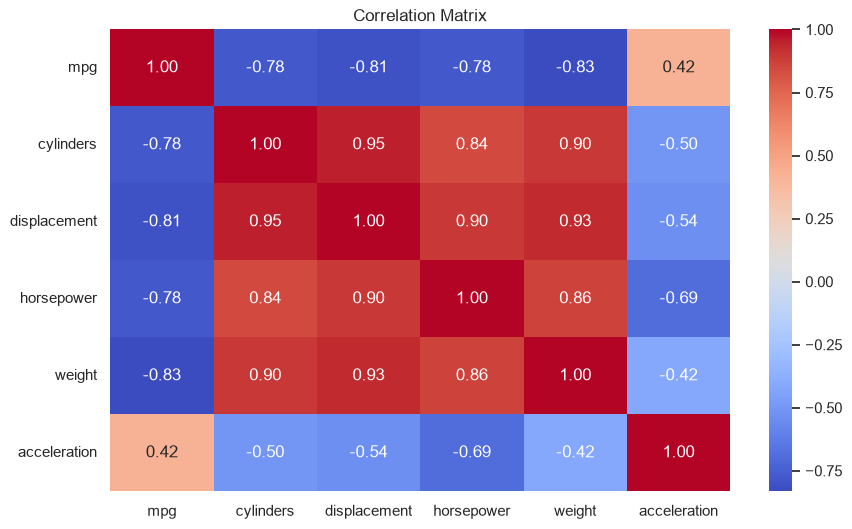

In [ ]:
# =====================================================================
# Calculate and Visualize the Correlation Matrix
# =====================================================================
#
# A correlation matrix summarizes the linear relationships between
# multiple numerical variables.
#
# The correlation coefficient ranges from -1 to +1:
#
#   +1  -> Perfect positive correlation
#    0  -> No linear correlation
#   -1  -> Perfect negative correlation
#
# Correlation measures the strength and direction of a linear
# relationship between two variables. """It does NOT imply causation."""
# =====================================================================


# =====================================================================
# Select the Numerical Variables
# =====================================================================
#
# Only numerical variables can be used to calculate Pearson's
# correlation coefficient.
# =====================================================================

numeric_cols = [
    "mpg",          # Miles per gallon - fuel efficiency
    "cylinders",   # Number of cylinders in the engine
    "displacement", # Engine displacement in cubic inches
    "horsepower",   # Engine power
    "weight",       # Vehicle weight in pounds
    "acceleration"  # Time to accelerate from 0 to 60 mph (seconds)
]


# =====================================================================
# Compute the Correlation Matrix
# =====================================================================
#
# The corr() method calculates the Pearson correlation coefficient
# between every pair of numerical variables.
#
# The result is a square matrix where:
#   • Rows represent variables.
#   • Columns represent variables.
#   • Each cell contains the correlation coefficient between two
#     variables.
#
# The diagonal values are always 1 because every variable is perfectly
# correlated with itself.
# =====================================================================

corr_matrix = mpg_clean[numeric_cols].corr()  # Calculate correlation matrix for selected numerical columns


# =====================================================================
# Visualize the Correlation Matrix Using a Heatmap
# =====================================================================
#
# A heatmap represents the correlation matrix using colors.
#
# Parameters:
#   annot=True  -> Display the correlation values inside each cell.
#   cmap        -> Use the "coolwarm" color palette.
#                  • Red  : Positive correlation
#                  • Blue : Negative correlation
#                  • White: Correlation close to zero
#   fmt=".2f"   -> Display values with two decimal places.
# =====================================================================

sns.heatmap(
    corr_matrix,
    annot=True,     # Show correlation coefficients on the heatmap
    cmap="coolwarm", # Color map: red for positive, blue for negative correlation
    fmt=".2f"       # Format numbers to two decimal places
)


# =====================================================================
# Add a Title and Display the Heatmap
# =====================================================================

plt.title("Correlation Matrix")  # Set the title for the heatmap
plt.show()  # Display the plot


**Observation:** MPG is strongly negatively correlated with weight, cylinders, displacement, and horsepower.

---

### 8.2 Simple Linear Regression: MPG ~ Weight

Fit a linear model and interpret the coefficients.

Intercept: 46.22
Coefficient (weight): -0.0076
R-squared: 0.6926


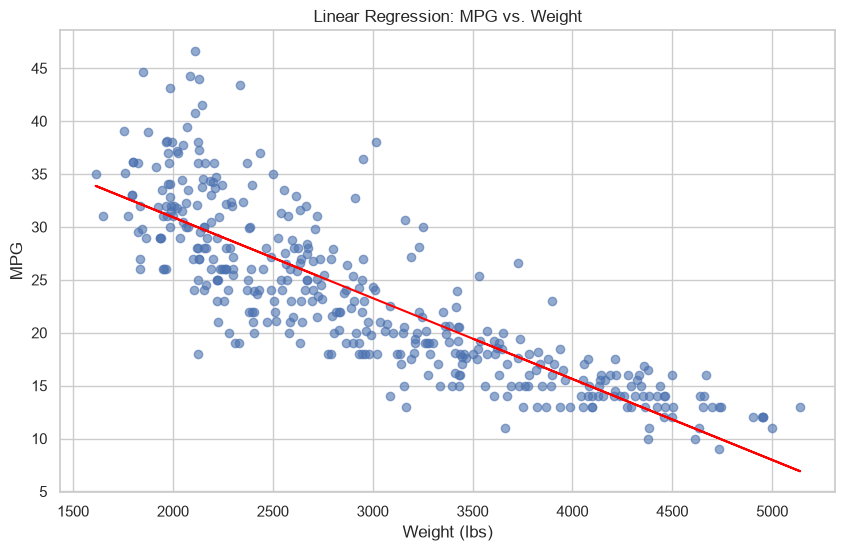

In [ ]:
# =====================================================================
# Perform Simple Linear Regression: Predict MPG from Vehicle Weight
# =====================================================================
#
# Linear regression is a supervised learning method used to model the
# relationship between a dependent variable (target) and one or more
# independent variables (features).
#
# In this example:
#
#   Independent variable (X):
#       Vehicle weight (lbs)
#
#   Dependent variable (y):
#       Fuel efficiency (MPG)
#
# The model learns a linear equation:
#
#       MPG = Intercept + (Coefficient × Weight)
#
# The coefficient shows how MPG changes when vehicle weight increases
# by one unit (one pound).
# =====================================================================


# Import the Linear Regression algorithm from Scikit-learn
#
# LinearRegression:
#   - Creates a model based on the Ordinary Least Squares (OLS) method.
#   - Finds the line that minimizes the difference between predicted
#     and actual values.
from sklearn.linear_model import LinearRegression



# =====================================================================
# Prepare the Input Feature (X)
# =====================================================================
#
# Select vehicle weight as the independent variable.
#
# Double brackets [[ ]] are used because Scikit-learn expects X to be a
# 2D array with the shape:
#
#       (number_of_samples, number_of_features)
#
# Example:
#       [[2500],
#        [3000],
#        [3500]]
#
# Here:
#   - Rows represent vehicles.
#   - Columns represent features.
# =====================================================================

X = mpg_clean[["weight"]].values


# =====================================================================
# Prepare the Target Variable (y)
# =====================================================================
#
# The target variable is MPG, which we want to predict.
#
# A single bracket [] returns a Pandas Series.
# The .values attribute converts it into a NumPy array, which is
# commonly used by Scikit-learn models.
# =====================================================================

y = mpg_clean["mpg"].values



# =====================================================================
# Create the Linear Regression Model
# =====================================================================
#
# LinearRegression():
#   - Initializes an empty regression model.
#   - The model parameters are learned after calling fit().
# =====================================================================

model = LinearRegression()



# =====================================================================
# Train (Fit) the Model
# =====================================================================
#
# fit(X, y):
#   - Learns the relationship between weight and MPG.
#   - Estimates:
#       • Intercept (β₀)
#       • Coefficient (β₁)
#
# After fitting, the model can make predictions using predict().
# =====================================================================

model.fit(X, y)



# =====================================================================
# Display Model Parameters
# =====================================================================
#
# Intercept:
#   - The predicted MPG when weight equals zero.
#   - Represents β₀ in the regression equation.
#
# Coefficient:
#   - Represents the change in MPG for each additional pound of weight.
#   - Represents β₁ in the regression equation.
#
# Note:
#   The coefficient is usually negative in this dataset because heavier
#   vehicles tend to have lower fuel efficiency.
# =====================================================================

print(f"Intercept: {model.intercept_:.2f}")

# model.coef_ contains coefficients for all input features.
# Since we have only one feature (weight), we access the first value.
print(f"Coefficient (weight): {model.coef_[0]:.4f}")



# =====================================================================
# Evaluate Model Performance Using R² Score
# =====================================================================
#
# score(X, y):
#   - Calculates the coefficient of determination (R²).
#
# R² interpretation:
#   • R² = 1.0  → Perfect prediction
#   • R² = 0    → Model explains no variance
#   • Higher values indicate better fit
#
# It represents the proportion of MPG variation explained by weight.
# =====================================================================

print(f"R-squared: {model.score(X, y):.4f}")



# =====================================================================
# Visualize the Regression Model
# =====================================================================
#
# The scatter plot shows:
#   - Actual vehicle observations
#   - Relationship between weight and MPG
#
# The red line represents the fitted linear regression model.
# It shows the predicted MPG values for different vehicle weights.
# =====================================================================


# Plot the original observations
plt.scatter(
    X,
    y,
    alpha=0.6   # Transparency helps visualize overlapping points
)


# Plot the regression prediction line
#
# predict(X):
#   - Uses the trained model to estimate MPG values.
plt.plot(
    X,
    model.predict(X),
    color="red"
)


# Add axis labels and title
plt.xlabel("Weight (lbs)")
plt.ylabel("MPG")
plt.title("Linear Regression: MPG vs. Weight")


# Display the final visualization
plt.show()



**Interpretation:** For every extra pound of weight, MPG decreases by about 0.0076 (i.e., 7.6 MPG per 1000 lbs). The R² ~ 0.69 means weight explains 69% of the variability in MPG.

---

### 8.3 Check Residuals

For a good regression, residuals should be normally distributed and have constant variance.

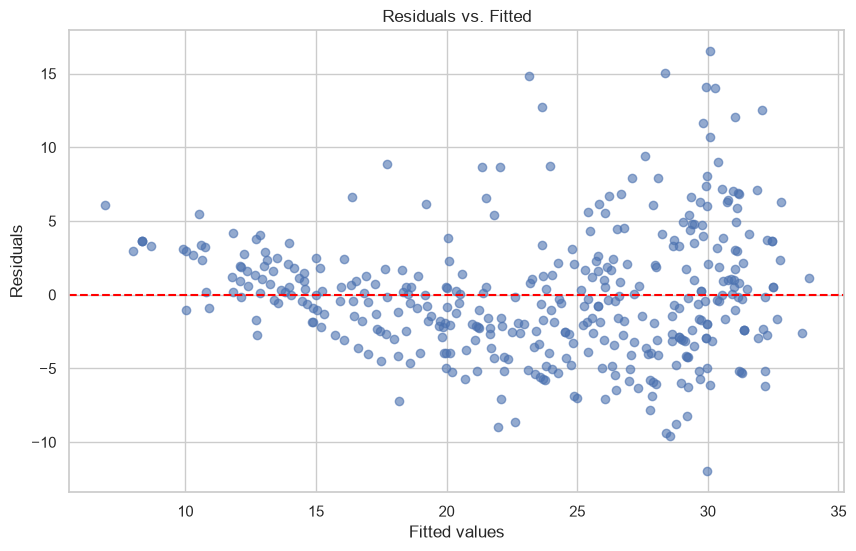

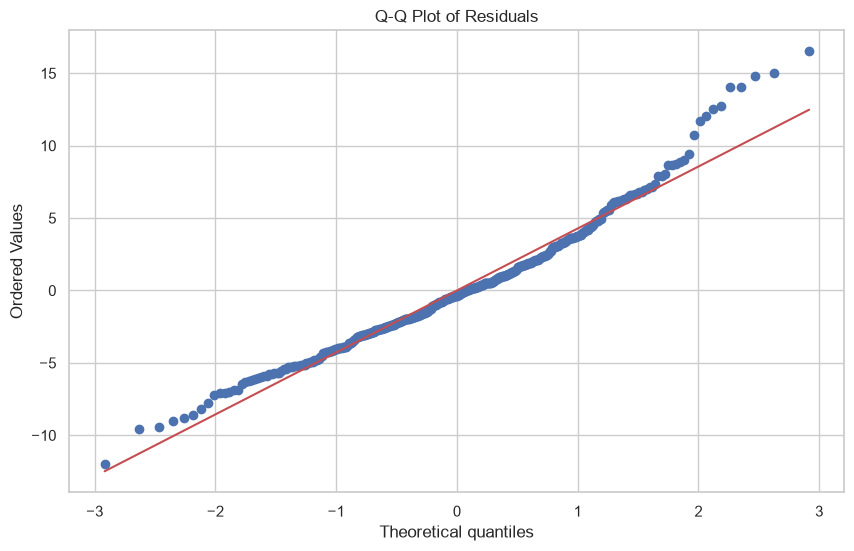

In [ ]:
# =====================================================================
# Analyze Regression Residuals
# =====================================================================
#
# Residual analysis is an important step after building a regression
# model because it helps evaluate whether the model assumptions are
# satisfied.
#
# A residual is the difference between the actual observed value and
# the value predicted by the model.
#
# Formula:
#
#       Residual = Actual Value - Predicted Value
#
# A good linear regression model should have residuals that:
#   • Are randomly distributed around zero.
#   • Have approximately constant variance.
#   • Follow a normal distribution.
#
# We evaluate residuals using:
#
#   1. Residuals vs. Fitted Values Plot
#      - Checks linearity and constant variance (homoscedasticity).
#
#   2. Q-Q Plot of Residuals
#      - Checks whether residuals approximately follow a normal
#        distribution.
# =====================================================================



# =====================================================================
# Calculate Residuals
# =====================================================================
#
# model.predict(X):
#   - Uses the trained regression model to generate predicted MPG values.
#
# Residuals:
#   - Positive residual → Model underestimated MPG.
#   - Negative residual → Model overestimated MPG.
# =====================================================================

residuals = y - model.predict(X)



# =====================================================================
# Residual Plot: Residuals vs. Fitted Values
# =====================================================================
#
# This plot compares:
#
#   x-axis:
#       Fitted values (predicted MPG from the model)
#
#   y-axis:
#       Residual values (prediction errors)
#
# Interpretation:
#
#   Good model:
#       Residuals are randomly scattered around zero.
#
#   Possible problems:
#       • Curved pattern → Relationship may not be linear.
#       • Increasing spread → Non-constant variance.
#       • Large isolated points → Possible outliers.
# =====================================================================

plt.scatter(
    model.predict(X),   # Predicted MPG values
    residuals,          # Difference between actual and predicted MPG
    alpha=0.6           # Transparency for overlapping points
)


# Add a horizontal reference line at residual = 0
#
# This line represents perfect predictions.
# Points above the line indicate underestimation.
# Points below the line indicate overestimation.
plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)


# Add labels and title
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted")


# Display residual plot
plt.show()



# =====================================================================
# Q-Q Plot of Residuals
# =====================================================================
#
# A Quantile-Quantile (Q-Q) plot compares the distribution of residuals
# against a theoretical normal distribution.
#
# Interpretation:
#
#   • Points close to the diagonal line:
#       Residuals are approximately normally distributed.
#
#   • Strong deviations from the line:
#       Residuals may not follow a normal distribution.
#
# Normal residuals are one of the assumptions of classical linear
# regression.
# =====================================================================

stats.probplot(
    residuals,
    dist="norm",    # Compare residuals with a normal distribution
    plot=plt
)


# Add title and display Q-Q plot
plt.title("Q-Q Plot of Residuals")
plt.show()


## 9. Summary and Next Steps

Congratulations! You have covered:

- Descriptive statistics (mean, median, mode, variance, std, IQR)
- Visualization (histograms, boxplots, scatterplots, pairplots)
- Normality checking (Q-Q, Shapiro‑Wilk)
- Confidence intervals
- Hypothesis tests (one‑sample, two‑sample, ANOVA)
- Correlation and simple linear regression

**Further explorations you can try:**
- Multiple linear regression (include more predictors)
- Transform variables (e.g., log) to improve normality
- Non‑parametric tests (Mann‑Whitney, Kruskal‑Wallis)
- Explore interaction terms or polynomial regression

---

*Happy analyzing!* 🚀

cool!